# traQmania 02 — Q-learning from scratch

In [notebook 01](01_the_racing_env.ipynb) we saw the racing environment: 4
observation features, 4 discrete actions, progress-based reward. Now we make an
agent *learn* to drive — with a classical neural network so small it will be
directly comparable to a 4-qubit quantum circuit later.

## The 60-second theory

Driving is a **Markov decision process**: at each step the agent sees a state
$s$, picks an action $a$, gets a reward $r$ and a next state $s'$. The
**Q-function** $Q(s, a)$ is the total discounted reward you can still collect
by taking action $a$ in state $s$ and playing well afterwards. The optimal
Q-function satisfies the Bellman equation

$$Q^*(s, a) = \mathbb{E}\left[\, r + \gamma \max_{a'} Q^*(s', a') \,\right],$$

and once you have it, the optimal policy is trivial: pick
$\arg\max_a Q(s, a)$.

**Deep Q-learning (DQN)** approximates $Q$ with a parameterized function and
regresses it onto the right-hand side of the Bellman equation, with three
stabilizing tricks used here:

- **replay buffer** — train on random past transitions, not just the latest ones
- **target network** — a slow-moving copy of the parameters computes the target
  $r + \gamma\, Q_\mathrm{target}(s', a^*)$, with the online network choosing
  $a^*$ (**double DQN**)
- **$\varepsilon$-greedy exploration** — act randomly with probability
  $\varepsilon$, annealed from 1.0 to 0.05

One detail concerns how an episode *ends*. Leaving the track is a real
terminal state: nothing more can be earned, so the target is just $r$.
Running into the 60 s time limit is not — the car is still on track and
would have kept collecting reward. That ending is a *truncation*, and the
target keeps bootstrapping from the state the car was in
(`bootstrap_truncation = true` in the default config; with `false` the
time limit is treated like a crash without the penalty).

The whole loop is a few hundred lines of numpy in
`traqmania.agents.training.dqn` — no deep-learning framework. That matters
later: the same loop will train the quantum circuit unchanged.

In [1]:
# On Binder (QuBins images) this repo arrives via nbgitpuller without being
# pip-installed; install it from GitHub only if the import fails.
try:
    import traqmania  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/JanLahmann/traQmania

import matplotlib.pyplot as plt
import numpy as np

## The classical Q-function

`MLPQFunction` is a single-hidden-layer network: 4 features → 8 tanh units → 4
Q-values, i.e. **76 parameters** in one flat vector. Every Q-function backend
in traQmania implements the same 4-method protocol (`q_values`,
`grad_selected`, `get_params`, `set_params`), which is all the trainer needs.

In [2]:
from traqmania.agents.classical import MLPQFunction

qfunc = MLPQFunction(n_features=4, hidden=8, n_actions=4, seed=0)
print(f"parameters: {qfunc.n_params}")
print("Q-values for one observation:", np.round(qfunc.q_values([[0.5, 1.0, 0.5, 0.3]]), 3))

parameters: 76
Q-values for one observation: [[-0.388 -0.571 -0.268  0.271]]


## Train it

300 episodes on the oval with the repository's default `[training]` recipe:
8 vectorized cars collecting experience in parallel, one gradient update per
environment decision. On a laptop this takes seconds to a few tens of seconds,
depending on what else the machine is doing (the cell prints it).
The `CleanLapMonitor` wrapper records the first episode in which a full lap
was driven without leaving the track. This is **one run with one seed** — a
demonstration of the loop, not a measurement.

In [3]:
import time

from traqmania.agents.training import DQNTrainer
from traqmania.config import load_config
from traqmania.env.racing_env import RacingEnv
from traqmania.env.track import Track
from traqmania.train_headless import CleanLapMonitor

config = load_config()
training_cfg = dict(config["training"])
training_cfg["seed"] = 0

track = Track.load("oval")
env = RacingEnv(track, config, n_envs=training_cfg["n_parallel_envs"], seed=0)
monitor = CleanLapMonitor(env)
qfunc = MLPQFunction(n_features=env.n_features, hidden=8, n_actions=4, seed=0)
trainer = DQNTrainer(qfunc, monitor, training_cfg, rng=np.random.default_rng(0))

print(f"recipe: gamma {training_cfg['gamma']}, lr {training_cfg['lr']}, epsilon "
      f"{training_cfg['epsilon_start']} -> {training_cfg['epsilon_end']} over "
      f"{training_cfg['epsilon_decay_episodes']} episodes, "
      f"bootstrap_truncation {training_cfg.get('bootstrap_truncation', False)}")
t0 = time.perf_counter()
history = trainer.train(episodes=300)
print(f"trained 300 episodes in {time.perf_counter() - t0:.1f} s")
print(f"first clean lap: episode {monitor.first_clean_episode} "
      f"(after {monitor.first_clean_wall_s:.1f} s of training)")
print(f"best lap during training: {monitor.best_lap_s:.1f} s")

recipe: gamma 0.98, lr 0.01, epsilon 1.0 -> 0.05 over 250 episodes, bootstrap_truncation True


trained 300 episodes in 24.6 s
first clean lap: episode 165 (after 3.4 s of training)
best lap during training: 12.7 s


## The learning curve

Per-episode returns are noisy (spawn jitter, exploration), so we overlay a
rolling mean. Reading the y-axis: the dotted line is what one clean lap is
worth — the track length in progress reward plus the checkpoint and lap
bonuses — so returns of several times that mean several laps per episode.

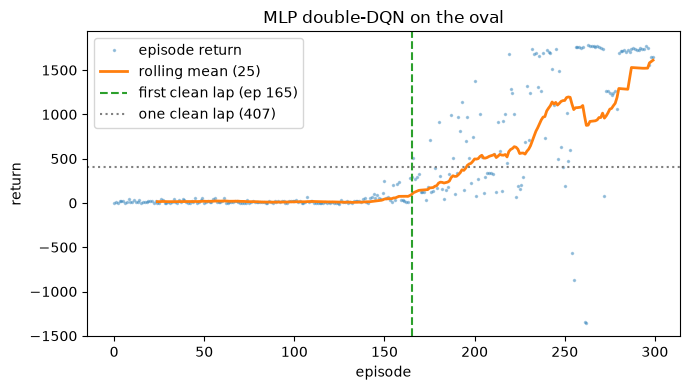

one clean lap of the oval is worth 407; mean return of the last 25 episodes: 1612


In [4]:
returns = np.array(history["episode_returns"])
window = 25
smooth = np.convolve(returns, np.ones(window) / window, mode="valid")

reward_cfg = config["reward"]
lap_reward = (reward_cfg["progress_scale"] * track.total_length
              + reward_cfg["checkpoint_bonus"] * len(track.checkpoints)
              + reward_cfg["lap_bonus"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(returns, ".", ms=3, alpha=0.35, label="episode return")
ax.plot(np.arange(window - 1, len(returns)), smooth, lw=2,
        label=f"rolling mean ({window})")
if monitor.first_clean_episode:
    ax.axvline(monitor.first_clean_episode, color="tab:green", ls="--",
               label=f"first clean lap (ep {monitor.first_clean_episode})")
ax.axhline(lap_reward, color="0.5", ls=":", label=f"one clean lap ({lap_reward:.0f})")
ax.set(xlabel="episode", ylabel="return", title="MLP double-DQN on the oval")
ax.legend()
plt.tight_layout()
plt.show()
print(f"one clean lap of the oval is worth {lap_reward:.0f}; mean return of the last "
      f"{window} episodes: {returns[-window:].mean():.0f}")

## Watch what it learned: greedy rollout

Set $\varepsilon = 0$ and let the network — with the parameters it has
after the last update — drive a fresh car from a standing start. The
trajectory is colored by speed — look for the learned racing behavior: full
throttle on the straights, slower through the turns.

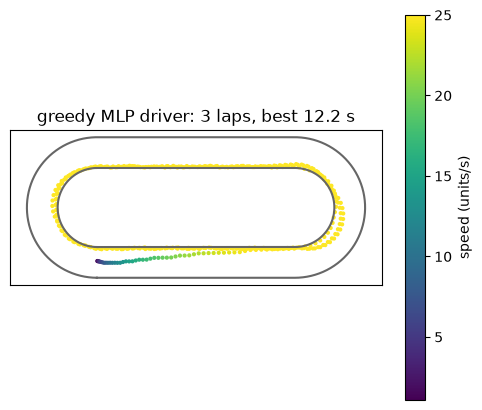

greedy rollout: 3 laps, best lap 12.2 s


In [5]:
def draw_track(ax, track):
    cl, hw = track.centerline, track.half_width
    for sign in (+1.0, -1.0):
        b = cl + sign * hw * track.normals
        b = np.vstack([b, b[:1]])
        ax.plot(b[:, 0], b[:, 1], color="0.4", lw=1.5)
    ax.set_aspect("equal")
    ax.set_xticks([]), ax.set_yticks([])


eval_env = RacingEnv(track, config, n_envs=1, seed=123)
obs = eval_env.reset()
xy, speed, best_lap, laps = [], [], np.inf, 0
for _ in range(400):
    actions = np.argmax(qfunc.q_values(obs), axis=1)  # greedy
    obs, reward, done, info = eval_env.step(actions)
    xy.append(eval_env.state[0, :2].copy())
    speed.append(eval_env.state[0, 3])
    if not np.isnan(info["last_lap_time"][0]):
        best_lap = min(best_lap, info["last_lap_time"][0])
    laps = max(laps, info["lap"][0])
    if done[0]:
        break
xy = np.array(xy)

fig, ax = plt.subplots(figsize=(6, 5))
draw_track(ax, track)
sc = ax.scatter(xy[:, 0], xy[:, 1], c=speed, s=4, cmap="viridis")
fig.colorbar(sc, ax=ax, label="speed (units/s)")
ax.set_title(f"greedy MLP driver: {laps} laps, best {best_lap:.1f} s")
plt.show()
print(f"greedy rollout: {laps} laps, best lap {best_lap:.1f} s")

Read the result off the outputs above: the episode of the first clean lap, and
what the final parameters do when they drive greedily. If the rollout
completed laps, a 76-parameter network has learned to lap the oval in seconds
of wall-clock time.

Keep in mind what this was: one seed, one start position, and the parameters
of the *last* update. A DQN's greedy policy keeps changing while it trains, so
the last parameters are not necessarily the best ones the run has seen — with
a different `seed` this same rollout can end off track even though the run
drove clean laps during training. That is why the training tools evaluate
greedy snapshots along the way and keep the best one, and why
[notebook 04](04_training_the_quantum_driver.ipynb) compares agents over many
seeds instead of one.

The key design point of traQmania: `DQNTrainer` only ever talks to the
Q-function through `q_values` / `grad_selected` / `get_params` / `set_params`.
Anything implementing those four methods can drive — including a quantum
circuit.

**Next:** [03 — Quantum circuits as Q-functions](03_quantum_circuits_as_q_functions.ipynb)
builds exactly that.